In [ ]:
# config bootstrap (auto-added): resolve repo paths from config.py
import os as _os, sys as _sys
_h = _os.path.abspath(_os.getcwd())
while not _os.path.exists(_os.path.join(_h, 'config.py')) and _os.path.dirname(_h) != _h:
    _h = _os.path.dirname(_h)
_sys.path.insert(0, _h)
import config as _cfg

# 3-Module Fusion — Fine-Tuned BLIP ITM + DeBERTa + SightEngine

Re-runs the 3-module fusion on the same 300 samples (150 real + 150 fake) from the original run,
but replaces pretrained BLIP ITM scores with fine-tuned checkpoint (epoch 9, F1: 75.1%).
- Keeps original DeBERTa + SightEngine scores (unchanged)
- 5-fold CV with Logistic Regression
- Compares against previous 3-module baseline of 82.67%

In [1]:
import json
import os

import torch
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from transformers import BlipProcessor, BlipForImageTextRetrieval
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

d:\Pics Can Lie\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# ── Load the original 300-sample 3-feature dataset ──
# This has the exact same samples, DeBERTa scores, and SightEngine scores from the baseline run
df_orig = pd.read_csv(_os.path.join(str(_cfg.ROOT), 'features', 'fusion_features_1000_3feat.csv'))
print(f"Original dataset: {len(df_orig)} samples")
print(f"  Real: {(df_orig['label']==0).sum()}, Fake: {(df_orig['label']==1).sum()}")
print(f"  Columns: {list(df_orig.columns)}")
print(f"\nOriginal BLIP ITM scores (pretrained):")
print(f"  REAL mean: {df_orig[df_orig['label']==0]['itm_score'].mean():.4f}")
print(f"  FAKE mean: {df_orig[df_orig['label']==1]['itm_score'].mean():.4f}")

Original dataset: 300 samples
  Real: 150, Fake: 150
  Columns: ['article_id', 'image_id', 'itm_score', 'entailment_score', 'sightengine_score', 'label', 'label_str']

Original BLIP ITM scores (pretrained):
  REAL mean: 0.6556
  FAKE mean: 0.2372


In [3]:
# ── Resolve image paths for these 300 samples to re-score with fine-tuned BLIP ──
DATASET_ROOT = _os.path.join(str(_cfg.ROOT), 'datasets', 'dataset')
METADATA_PATH = os.path.join(DATASET_ROOT, "data", "NewsClipPings", "metadata", "train.json")
IMAGE_BASE = os.path.join(DATASET_ROOT, "origin")

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

def resolve_image_path(meta_image_path: str) -> str:
    rel = meta_image_path.replace("visual_news/", "", 1)
    return os.path.join(IMAGE_BASE, rel)

# Build image_path and caption for each row
image_paths = []
captions = []
missing = 0
for _, row in df_orig.iterrows():
    art_id = str(row["article_id"])
    img_id = str(row["image_id"])
    
    img_path = resolve_image_path(metadata[img_id]["image_path"])
    caption = metadata[art_id]["caption"]
    
    if not os.path.isfile(img_path):
        missing += 1
    
    image_paths.append(img_path)
    captions.append(caption)

print(f"Resolved {len(image_paths)} image paths ({missing} missing)")

Resolved 300 image paths (0 missing)


In [4]:
# ── Re-score with fine-tuned BLIP ITM ──
FINETUNED_BLIP_DIR = _os.path.join(str(_cfg.ROOT), 'models', 'blip_itm_finetuned')

print(f"Loading fine-tuned BLIP from {FINETUNED_BLIP_DIR}...")
blip_processor = BlipProcessor.from_pretrained(FINETUNED_BLIP_DIR)
blip_model = BlipForImageTextRetrieval.from_pretrained(FINETUNED_BLIP_DIR).to(device).eval()
print(f"Loaded on {device}")

ft_itm_scores = []
for img_path, caption in tqdm(zip(image_paths, captions), total=len(image_paths), desc="BLIP ITM (fine-tuned)"):
    image = Image.open(img_path).convert("RGB")
    inputs = blip_processor(images=image, text=caption, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = blip_model(**inputs, use_itm_head=True)
        probs = torch.softmax(outputs.itm_score, dim=1)
        ft_itm_scores.append(probs[0, 1].item())

del blip_model, blip_processor
torch.cuda.empty_cache()

print(f"\nFine-tuned BLIP scores: min={min(ft_itm_scores):.4f}, max={max(ft_itm_scores):.4f}, mean={np.mean(ft_itm_scores):.4f}")
print(f"\nScore comparison (mean):")
print(f"  {'':>12s} {'Pretrained':>12s} {'Fine-tuned':>12s} {'Delta':>10s}")
real_mask = df_orig['label'] == 0
fake_mask = df_orig['label'] == 1
ft_scores = np.array(ft_itm_scores)
orig_scores = df_orig['itm_score'].values
print(f"  {'REAL':>12s} {orig_scores[real_mask].mean():>12.4f} {ft_scores[real_mask].mean():>12.4f} {ft_scores[real_mask].mean() - orig_scores[real_mask].mean():>+10.4f}")
print(f"  {'FAKE':>12s} {orig_scores[fake_mask].mean():>12.4f} {ft_scores[fake_mask].mean():>12.4f} {ft_scores[fake_mask].mean() - orig_scores[fake_mask].mean():>+10.4f}")
print(f"  {'Separation':>12s} {orig_scores[real_mask].mean() - orig_scores[fake_mask].mean():>12.4f} {ft_scores[real_mask].mean() - ft_scores[fake_mask].mean():>12.4f}")

Loading fine-tuned BLIP from D:\Pics Can Lie\blip_itm_finetuned...


Loading weights: 100%|██████████| 472/472 [00:00<00:00, 3743.44it/s]


Loaded on cuda


BLIP ITM (fine-tuned): 100%|██████████| 300/300 [00:17<00:00, 17.19it/s]


Fine-tuned BLIP scores: min=0.0038, max=0.9982, mean=0.4953

Score comparison (mean):
                 Pretrained   Fine-tuned      Delta
          REAL       0.6556       0.7422    +0.0866
          FAKE       0.2372       0.2484    +0.0112
    Separation       0.4184       0.4938


In [5]:
# ── Build updated feature matrix ──
df = df_orig.copy()
df["itm_score_pretrained"] = df["itm_score"]  # keep original for comparison
df["itm_score"] = ft_itm_scores  # replace with fine-tuned

print("Updated feature summary:")
print(df.groupby("label_str")[["itm_score", "entailment_score", "sightengine_score"]].agg(["mean", "std"]).round(4))

df.to_csv(_os.path.join(str(_cfg.ROOT), 'features', 'fusion_features_300_3feat_finetuned.csv'), index=False)
print("\nSaved to fusion_features_300_3feat_finetuned.csv")

Updated feature summary:
          itm_score         entailment_score         sightengine_score        
               mean     std             mean     std              mean     std
label_str                                                                     
FAKE         0.2484  0.2582           0.0740  0.1983            0.0000  0.0000
REAL         0.7422  0.2418           0.2573  0.4165            0.0174  0.0767

Saved to fusion_features_300_3feat_finetuned.csv


In [6]:
# ── 5-Fold CV: 3 features (fine-tuned BLIP + DeBERTa + SightEngine) ──
X = df[["itm_score", "entailment_score", "sightengine_score"]].values
y = df["label"].values

print(f"Features: Fine-Tuned BLIP ITM + DeBERTa + SightEngine (3 features)")
print(f"Samples: {len(X)} ({sum(y==0)} real, {sum(y==1)} fake)")
print(f"Method: 5-fold stratified cross-validation\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results_3f = []
all_y_true_3f = []
all_y_pred_3f = []
all_y_prob_3f = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = LogisticRegression(random_state=42, max_iter=1000)
    clf.fit(X_train_scaled, y_train)

    y_pred = clf.predict(X_test_scaled)
    y_prob = clf.predict_proba(X_test_scaled)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    fold_results_3f.append({"fold": fold+1, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1})
    all_y_true_3f.extend(y_test)
    all_y_pred_3f.extend(y_pred)
    all_y_prob_3f.extend(y_prob)

    print(f"  Fold {fold+1}: Acc={acc:.1%}  Prec={prec:.1%}  Rec={rec:.1%}  F1={f1:.1%}")

fold_df_3f = pd.DataFrame(fold_results_3f)
print(f"\n{'=' * 70}")
print(f"5-FOLD CV — FINE-TUNED BLIP + DeBERTa + SightEngine — {len(X)} samples")
print(f"{'=' * 70}")
print(f"  Mean Accuracy  : {fold_df_3f['accuracy'].mean():.2%} (+/- {fold_df_3f['accuracy'].std():.2%})")
print(f"  Mean Precision : {fold_df_3f['precision'].mean():.2%} (+/- {fold_df_3f['precision'].std():.2%})")
print(f"  Mean Recall    : {fold_df_3f['recall'].mean():.2%} (+/- {fold_df_3f['recall'].std():.2%})")
print(f"  Mean F1 Score  : {fold_df_3f['f1'].mean():.2%} (+/- {fold_df_3f['f1'].std():.2%})")
print(f"{'=' * 70}")

all_y_true_3f = np.array(all_y_true_3f)
all_y_pred_3f = np.array(all_y_pred_3f)
all_y_prob_3f = np.array(all_y_prob_3f)

print(f"\nClassification report:")
print(classification_report(all_y_true_3f, all_y_pred_3f, target_names=["REAL", "FAKE"]))

cm_3f = confusion_matrix(all_y_true_3f, all_y_pred_3f)
cm_df_3f = pd.DataFrame(cm_3f, index=["Actual REAL", "Actual FAKE"], columns=["Pred REAL", "Pred FAKE"])
display(cm_df_3f)

print(f"\nFeature weights (last fold):")
for name, coef in zip(["BLIP ITM (fine-tuned)", "DeBERTa Entailment", "SightEngine AI"], clf.coef_[0]):
    print(f"  {name:>25s}: {coef:+.4f}")

Features: Fine-Tuned BLIP ITM + DeBERTa + SightEngine (3 features)
Samples: 300 (150 real, 150 fake)
Method: 5-fold stratified cross-validation

  Fold 1: Acc=88.3%  Prec=84.8%  Rec=93.3%  F1=88.9%
  Fold 2: Acc=93.3%  Prec=90.6%  Rec=96.7%  F1=93.5%
  Fold 3: Acc=88.3%  Prec=92.6%  Rec=83.3%  F1=87.7%
  Fold 4: Acc=90.0%  Prec=90.0%  Rec=90.0%  F1=90.0%
  Fold 5: Acc=88.3%  Prec=92.6%  Rec=83.3%  F1=87.7%

5-FOLD CV — FINE-TUNED BLIP + DeBERTa + SightEngine — 300 samples
  Mean Accuracy  : 89.67% (+/- 2.17%)
  Mean Precision : 90.13% (+/- 3.17%)
  Mean Recall    : 89.33% (+/- 5.96%)
  Mean F1 Score  : 89.58% (+/- 2.41%)

Classification report:
              precision    recall  f1-score   support

        REAL       0.89      0.90      0.90       150
        FAKE       0.90      0.89      0.90       150

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300



,Pred REAL,Pred FAKE
Actual REAL,135,15
Actual FAKE,16,134



Feature weights (last fold):
      BLIP ITM (fine-tuned): -1.8256
         DeBERTa Entailment: -0.7385
             SightEngine AI: -3.8071


In [7]:
# ── Also run 2-feature (fine-tuned BLIP + DeBERTa only) for comparison ──
X_2f = df[["itm_score", "entailment_score"]].values

fold_results_2f = []
for fold, (train_idx, test_idx) in enumerate(skf.split(X_2f, y)):
    X_train, X_test = X_2f[train_idx], X_2f[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf_2f = LogisticRegression(random_state=42, max_iter=1000)
    clf_2f.fit(X_train_scaled, y_train)
    y_pred = clf_2f.predict(X_test_scaled)

    fold_results_2f.append({
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    })

fold_df_2f = pd.DataFrame(fold_results_2f)
print(f"2-feature (FT BLIP + DeBERTa): Acc={fold_df_2f['accuracy'].mean():.2%}, F1={fold_df_2f['f1'].mean():.2%}")

2-feature (FT BLIP + DeBERTa): Acc=85.00%, F1=84.84%


In [8]:
# ── Comparison table ──
ft_3f_acc = fold_df_3f['accuracy'].mean()
ft_3f_f1  = fold_df_3f['f1'].mean()
ft_2f_acc = fold_df_2f['accuracy'].mean()
ft_2f_f1  = fold_df_2f['f1'].mean()
baseline_3f_acc = 0.8267
baseline_2f_acc = 0.76

print("=" * 75)
print("COMPARISON: All Fusion Configurations")
print("=" * 75)
print(f"{'Configuration':<45s} {'Accuracy':>12s} {'F1':>8s} {'vs Baseline':>12s}")
print("-" * 75)
print(f"{'Pretrained BLIP + DeBERTa (2000 samples)':<45s} {baseline_2f_acc:>12.2%} {'76.01%':>8s} {'—':>12s}")
print(f"{'Pretrained BLIP + DeBERTa + SE (300 samples)':<45s} {baseline_3f_acc:>12.2%} {'—':>8s} {'—':>12s}")
print(f"{'Fine-tuned BLIP + DeBERTa (300 samples)':<45s} {ft_2f_acc:>12.2%} {ft_2f_f1:>8.2%} {ft_2f_acc - baseline_2f_acc:>+12.2%}")
print(f"{'Fine-tuned BLIP + DeBERTa + SE (300 samples)':<45s} {ft_3f_acc:>12.2%} {ft_3f_f1:>8.2%} {ft_3f_acc - baseline_3f_acc:>+12.2%}")
print("-" * 75)
print(f"\nFine-tuned BLIP checkpoint: epoch 9, val F1: 75.1%")
print(f"SE = SightEngine AI-generated detection")

COMPARISON: All Fusion Configurations
Configuration                                     Accuracy       F1  vs Baseline
---------------------------------------------------------------------------
Pretrained BLIP + DeBERTa (2000 samples)            76.00%   76.01%            —
Pretrained BLIP + DeBERTa + SE (300 samples)        82.67%        —            —
Fine-tuned BLIP + DeBERTa (300 samples)             85.00%   84.84%       +9.00%
Fine-tuned BLIP + DeBERTa + SE (300 samples)        89.67%   89.58%       +7.00%
---------------------------------------------------------------------------

Fine-tuned BLIP checkpoint: epoch 9, val F1: 75.1%
SE = SightEngine AI-generated detection


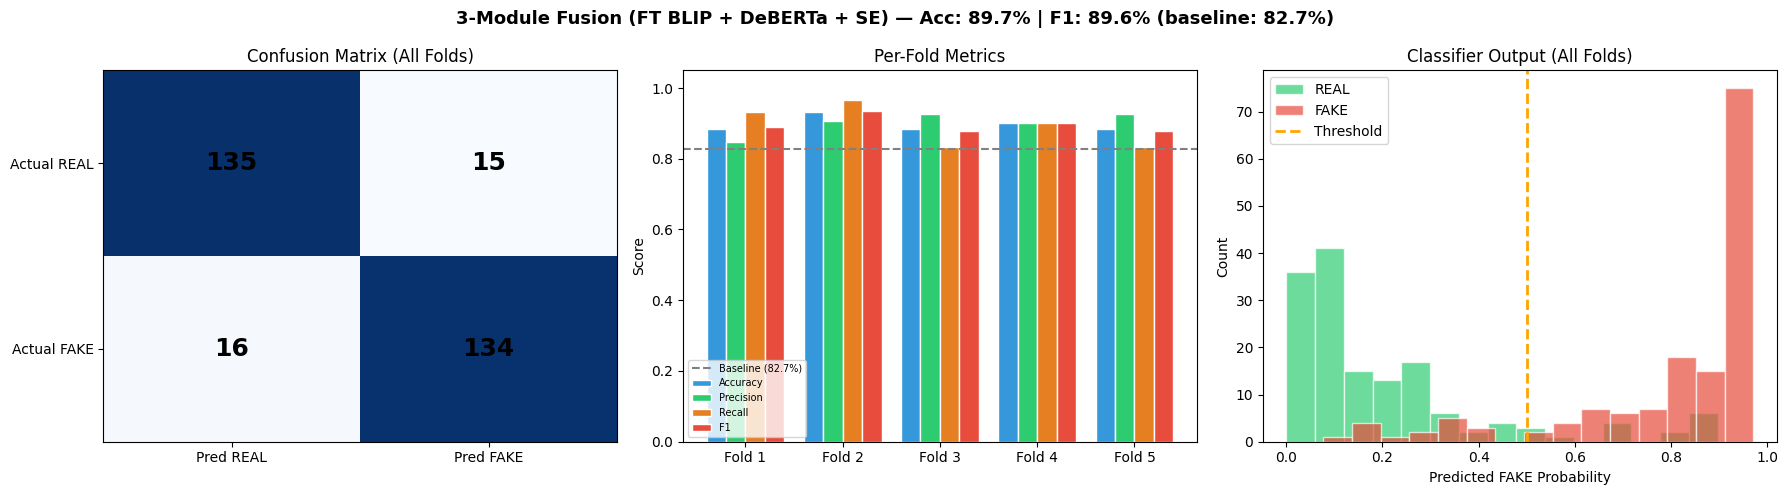

Plot saved to fusion_3module_finetuned_results.png


In [9]:
# ── Visualizations ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion matrix
ax = axes[0]
im = ax.imshow(cm_3f, cmap="Blues", aspect="auto")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred REAL", "Pred FAKE"])
ax.set_yticklabels(["Actual REAL", "Actual FAKE"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_3f[i, j]), ha="center", va="center", fontsize=18, fontweight="bold")
ax.set_title("Confusion Matrix (All Folds)")

# 2. Per-fold metrics with baseline
ax = axes[1]
x = np.arange(5)
w = 0.2
ax.bar(x - 1.5*w, fold_df_3f["accuracy"], w, label="Accuracy", color="#3498db", edgecolor="white")
ax.bar(x - 0.5*w, fold_df_3f["precision"], w, label="Precision", color="#2ecc71", edgecolor="white")
ax.bar(x + 0.5*w, fold_df_3f["recall"], w, label="Recall", color="#e67e22", edgecolor="white")
ax.bar(x + 1.5*w, fold_df_3f["f1"], w, label="F1", color="#e74c3c", edgecolor="white")
ax.axhline(y=baseline_3f_acc, color="gray", linestyle="--", linewidth=1.5, label=f"Baseline ({baseline_3f_acc:.1%})")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-Fold Metrics")
ax.legend(fontsize=7)

# 3. Probability distribution
ax = axes[2]
real_probs = all_y_prob_3f[all_y_true_3f == 0]
fake_probs = all_y_prob_3f[all_y_true_3f == 1]
ax.hist(real_probs, bins=15, alpha=0.7, color="#2ecc71", label="REAL", edgecolor="white")
ax.hist(fake_probs, bins=15, alpha=0.7, color="#e74c3c", label="FAKE", edgecolor="white")
ax.axvline(x=0.5, color="orange", linestyle="--", linewidth=2, label="Threshold")
ax.set_xlabel("Predicted FAKE Probability")
ax.set_ylabel("Count")
ax.set_title("Classifier Output (All Folds)")
ax.legend()

plt.suptitle(f"3-Module Fusion (FT BLIP + DeBERTa + SE) — Acc: {ft_3f_acc:.1%} | F1: {ft_3f_f1:.1%} (baseline: {baseline_3f_acc:.1%})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(_os.path.join(str(_cfg.ROOT), 'results', 'fusion_3module_finetuned_results.png'), dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to fusion_3module_finetuned_results.png")